# k-Nearest Neighbors (k-NN) Classification

Implementation and evaluation of the k-NN algorithm on 2D synthetic datasets, featuring decision boundary visualization and k-fold cross-validation.


In [1]:
# Automatically reload modules when changed
%reload_ext autoreload
%autoreload 2
# Plot figures "inline" with other output
%matplotlib inline

# Import modules, classes, functions
from datetime import timedelta
from time import perf_counter as tic

from matplotlib import pyplot as plt
import numpy as np

from utils import plotDatasets, loadDataset, splitData, splitDataBins, getCVSplit, plotResultsCV, plotResultsDots, plotConfusionMatrixOCR
from evalFunctions import calcConfusionMatrix, calcAccuracy, calcAccuracyCM

# Configure nice figures
plt.rcParams['figure.facecolor']='white'
plt.rcParams['figure.figsize']=(8,5)

### ***! IMPORTANT NOTE !***

> **Implementation Note**: This module is implemented using pure NumPy to demonstrate the core mathematical mechanics from first principles without high-level library abstractions.

### **1. Introduction**

The focus of this assignment is **supervised learning**. In particular, you will apply several machine learning algorithms to solve classification tasks. Throughout the three notebooks that consistute this assignment you will implement a kNN classifier, as well as single-layer and two-layer neural networks.

#### **1.1 Data**

Let's start by examining the datasets used in this assignments. Run the following cell to visualize the datasets.

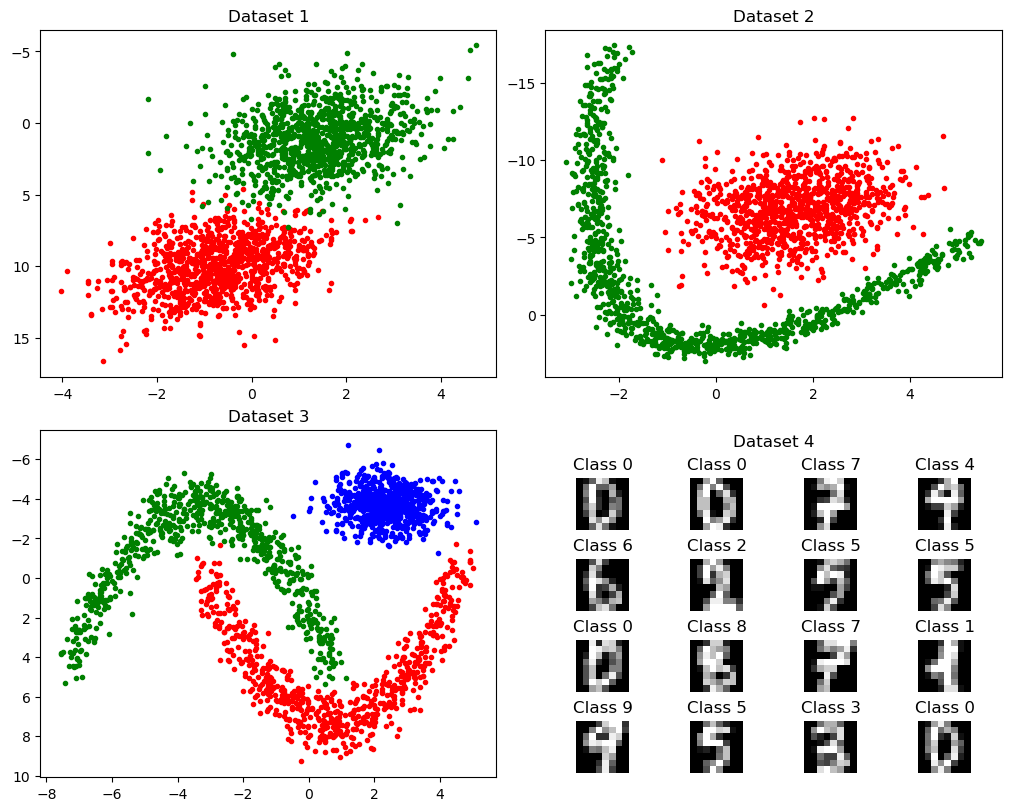

In [2]:
plotDatasets()

As you can see, datasets 1, 2 and 3 are point clouds with various shapes and number of classes, while dataset 4 consists of 8x8 pixel images of handwritten digits (these are stored as 64-length vectors). Each dataset in this assignment consists of three variables:
- `X` contains the input features for the data samples.
- `D` contains neural network target output values for the data samples. These are not used with kNN, and will be explained in the other notebooks in this assignment.
- `L` contains the class labels for the data samples.

Use the code in the next cell to load and examine all four datasets. Note that this assignment follows the convention that data samples are in the rows of a matrix, while features are in the columns.

In [34]:
datasetNr = 1
X, D, L = loadDataset(datasetNr)

print(f"X has shape {X.shape}") # Feature matrix: 2000 samples x 2 features --> Each point has 2 features (x,y)
print(f"D has shape {D.shape}") # 2 classes. 2000 samples x 2 classes
print(f"L has shape {L.shape}") # One label for every sample, 1 column with only the answers (0 or 1)

datasetNr = 2
X, D, L = loadDataset(datasetNr)

print(f"X has shape {X.shape}") # Feature matrix: 2000 samples x 2 features --> Each point has 2 features (x,y)
print(f"D has shape {D.shape}") # 2 classes. 2000 samples x 2 classes
print(f"L has shape {L.shape}") # One label for every sample, 1 column with only the answers (0 or 1)

datasetNr = 3
X, D, L = loadDataset(datasetNr)

print(f"X has shape {X.shape}") # Feature matrix: 2000 samples x 2 features --> Each point has 2 features (x,y)
print(f"D has shape {D.shape}") # 3 classes. 2000 samples x 3 classes
print(f"L has shape {L.shape}") # One label for every sample, 1 column with only the answers (0 to 2)

datasetNr = 4
X, D, L = loadDataset(datasetNr)

print(f"X has shape {X.shape}") # Feature matrix: 5620 samples x 64 features --> 64 pixel brightness values.
print(f"D has shape {D.shape}") # It has 10 classes (representing digits 0–9).
print(f"L has shape {L.shape}") # One label for every sample, 1 column with only the answers (0 to 9)

# Print a sample of the X dataset
sample_size = 2000  # Number of samples to print
print(f"Sample of X (first {sample_size} labels): {X[:sample_size]}")

# Print a sample of the D dataset
sample_size = 2000  # Number of samples to print
print(f"Sample of D (first {sample_size} labels): {D[:sample_size]}")

# Print a sample of the L dataset
sample_size = 2000  # Number of samples to print
print(f"Sample of L (first {sample_size} labels): {L[:sample_size]}")



X has shape (2000, 2)
D has shape (2000, 2)
L has shape (2000,)
X has shape (2000, 2)
D has shape (2000, 2)
L has shape (2000,)
X has shape (2000, 2)
D has shape (2000, 3)
L has shape (2000,)
X has shape (5620, 64)
D has shape (5620, 10)
L has shape (5620,)
Sample of X (first 2000 labels): [[ 0.  1.  6. ...  1.  0.  0.]
 [ 0.  0. 10. ...  3.  0.  0.]
 [ 0.  0.  8. ...  0.  0.  0.]
 ...
 [ 0.  0.  2. ...  9.  0.  0.]
 [ 0.  0.  5. ...  2.  0.  0.]
 [ 0.  0.  7. ...  0.  0.  0.]]
Sample of D (first 2000 labels): [[ 0.99 -0.99 -0.99 ... -0.99 -0.99 -0.99]
 [ 0.99 -0.99 -0.99 ... -0.99 -0.99 -0.99]
 [-0.99 -0.99 -0.99 ...  0.99 -0.99 -0.99]
 ...
 [ 0.99 -0.99 -0.99 ... -0.99 -0.99 -0.99]
 [-0.99  0.99 -0.99 ... -0.99 -0.99 -0.99]
 [-0.99 -0.99 -0.99 ...  0.99 -0.99 -0.99]]
Sample of L (first 2000 labels): [0 0 7 ... 0 1 7]


#### **<span style="color:red">Question 1:</span>**
Describe all four datasets used in this assignment from a machine learning perspective:
- What does the dataset represent? What kind of data is it made of, and what can you tell about its arrangement?
- How many samples are in each dataset? How many features do they have?
- How many classes does each dataset have? What do they represent?
- Will the dataset require a linear or nonlinear classifier? Why?

#### **<span style="color:green">Answer:</span>**


Dataset 1: 
- 2D point cloud. The points are arranged in two distinct clusters that look linearly separable.
- It has 2,000 samples with 2 features each (x, y coordinates).
- There are 2 classes. They represent two different groups or categories of points in this 2D space.
- A linear classifier should work well here because the two clusters are clearly separated and don't overlap in a complex way.

Dataset 2:
- 2D point cloud. The data is arranged in a "half moon" shape where one class is in the center and the other class surrounds it.
- It has 2,000 samples with 2 features each (x, y coordinates).
- There are 2 classes (inner circle vs. outer ring).
- This set requires a nonlinear classifier. You cannot draw a single straight line to separate the inner circle from the outer ring; you'd need a more circular boundary.

Dataset 3:
- A 2D point cloud with a spiral pattern and blob pattern. Two classes swirl around each other while the third class is centered.
- It has 2,000 samples with 2 features each (x, y coordinates).
- There are 3 classes
- This requires a nonlinear classifier. A straight line would fail completely here because the decision boundary needs to follow the complex spiral path.

Dataset 4:
- This dataset consists of grayscale images of handwritten digits. The 8x8 pixel images are flattened into vectors. 
- There are 5,620 samples. Each sample has 64 features (since 8 * 8 = 64).
- There are 10 classes, representing the digits 0 through 9.
- A linear classifier can work but nonlinear classifier is usually necessary for high performance on more advnaced data, as the relationships between pixels and digit labels are complex. 

---
### **2. The kNN classifier**

k-nearest neighbors (kNN) is a relatively simple classification algorithm, that nevertheless can be quite effective. It is a nonlinear classifier where each new sample is assigned the class that most commonly appears among its neighbors in the training data, i.e. those training samples with the shortest distance to it. Distances in kNN can actually be defined in many different ways based on the application, but here we will use the most common Euclidean distance. The number of neighboring samples to consider, called k, is the only parameter of the algorithm. Depending on the specific properties of the problem, different values of k might give optimal results.

Unlike other types of classifiers, such as support vector machines and neural networks, kNN does not have any trainable parameters, and thus requires no training. It does, however, require a training dataset, which is effectively "memorized", and used as reference to classify all future data. This has the advantage of no training time, but results in slow inference times, which are proportional to the amount of training data.

#### **2.1 Implement the kNN algorithm**

The `kNN` function takes as input arguments the set of samples to be classified `X`, the number of neighbors to consider `k`, an the training samples `XTrain` and labels `LTrain`. There are different ways to implement the kNN algorithm, but we recommend you to follow these steps:

1. Calculate the Euclidean distances between every point in `X` and every point in `XTrain` and save them in a large matrix. Recall that the Eucliden distance between two $N$-dimensional points $\mathbf{x}$ and $\mathbf{y}$ is given as

$$ \large d = \sqrt{\sum_{i=1}^N (x_i - y_i)^2} .$$

Your implementation should not assume any specific number of features in the data, but should work for data of any number of features.

2. From each row of the matrix, select the `k` points with the smallest distance.

3. Find the class that appears most often among the `k` closest points and assign it to the corresponding point in `X`.

4. Sometimes there is a draw between two neighboring classes. Detect this and implement a strategy for choosing the class.

Keep in mind that, as was said previously, classifying data with kNN can be time-consuming, and an efficient implementation can really save you some time in the long run (especially once we implement cross-validation in section 3). Because of this, it is recommended that you avoid loops as much as possible, and instead take full advantage of `numpy`'s capacity for operating directly on arrays using either matrix multiplication or [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html). See some more instructions in the code cell below.

In [4]:
def kNN(X, k, XTrain, LTrain):
    """ KNN
    Your implementation of the kNN algorithm.

    Args:
        X (array): Samples to be classified.
        k (int): Number of neighbors.
        XTrain (array): Training samples.
        LTrain (array): Correct labels of each sample.

    Returns:
        LPred (array): Predicted labels for each sample.
    """

    classes = np.unique(LTrain)
    nClasses = classes.shape[0]

    # --------------------------------------------
    # === Your code here =========================
    # --------------------------------------------
    
    # 1. Calculate Euclidean distances between X and XTrain using broadcasting
    # Adds dimensions to allow broadcasting: 
    # X (M, F) becomes 3D matrix (M, 1, F) and XTrain (N, F) becomes 3D matrix (1, N, F)
    # The resulting shape is: (NumTest, NumTrain, Features)
    diff = X[:, np.newaxis, :] - XTrain[np.newaxis, :, :]
    
    # Square the differences to get the distance
    diff_sq = diff ** 2
    # We squash the feature dimension. 
    # Result shape: (NumTest, NumTrain) <- Distance Matrix
    dist_summed = np.sum(diff_sq, axis=2)
    dists_sq = np.sqrt(dist_summed) # <-- Matrix with every test point and training point distance
        
    # 2. Sort distances to find indices (index) of k closest neighbors
    # argsort returns the indices that WOULD sort the array but it doesnt actually sort it
    sorted_indices = np.argsort(dists_sq, axis=1)
    
    # Keep only the first k indices
    k_closest_indices = sorted_indices[:, :k] # <-- For example [413, 35, 142]
    
    # Get the labels corresponding to those k indices
    k_closest_labels = LTrain[k_closest_indices]

    # 3. & 4. Find most common label (Voting) and handle ties
    # Create an empty matrix to count votes for each class: (Num_Samples, Num_Classes)
    vote_counts = np.zeros((X.shape[0], nClasses))
    
    # Populate the matrix by counting occurrences of each class in the neighbor set
    for i, c in enumerate(classes):
        vote_counts[:, i] = np.sum(k_closest_labels == c, axis=1) # <-- Count how many times class c appears in the k closest labels for each test sample
    
    # Find the index of the class with the maximum votes
    # np.argmax handles ties by returning the first occurrence of the max value
    # (effectively choosing the class with the lower ID in case of a tie)
    winner_indices = np.argmax(vote_counts, axis=1)
    
    # Map indices back to original class labels
    LPred = classes[winner_indices]
        
    # ============================================
    
    return LPred

#### **2.2 Test it on some data**

In order to test your implementation, you will first need to split the available data into training and test sets. You can then classify the test data using the training data as reference. Use the `splitData` function for this purpose.

In [5]:
# Select and load dataset
# X (array): Data samples. D (array): Neural network target values. L (array): Class labels.
datasetNr = 1
X, D, L = loadDataset(datasetNr)

# Split data into training set (85%) and test set (15%)
XTrain, _, LTrain, XTest, _, LTest = splitData(X, D, L, 0.15)

Set a value for `k` and classify the training and test data.

In [6]:
# Set the number of neighbors
k = 4

# Classify training data
LPredTrain = kNN(XTrain, k, XTrain, LTrain)
# Classify test data
LPredTest  = kNN(XTest , k, XTrain, LTrain)

Calculate and print the training and test accuracies as well as the confusion matrix for the test data. For this to work, you first need to open the file `evalFunctions.py` and implement the functions `calcAccuracy`, `calcConfusionMatrix`, and `calcAccuracyCM`, based on the function descriptions.

In [7]:
# Calculate the training and test accuracy
accTrain = calcAccuracy(LPredTrain, LTrain)
accTest = calcAccuracy(LPredTest, LTest)
print(f"Train accuracy: {accTrain:.4f}")
print(f"Test accuracy: {accTest:.4f}")

# Calculate confunsion matrix of test data
confMatrix = calcConfusionMatrix(LPredTest, LTest)
print()
print("Test data confusion matrix:")
print(confMatrix)

accTestCM = calcAccuracyCM(confMatrix)
print()
print(f"Test accuracy from CM: {accTestCM:.4f}")

Train accuracy: 0.9912
Test accuracy: 0.9967

Test data confusion matrix:
[[152   1]
 [  0 147]]

Test accuracy from CM: 0.9967


Now we can use some plotting functions to examine the classified training and test data, as well as the decision boundaries that separate the various classes. We will use these types of visualizations for all three classifier types.

For datasets 1-3 you will see classification results for the training and test data, where correctly classified samples appear in green and incorrectly classified samples appear in red. The backgrounds of these plots show in grayscale colors the different regions of the feature space which are assigned each class by the classifier. This is especially useful in order to examine the shape of the decision boundaries.

For the dataset 4 you will see a plot that shows examples of each type of correct and incorrect classification as given by the confusion matrix.

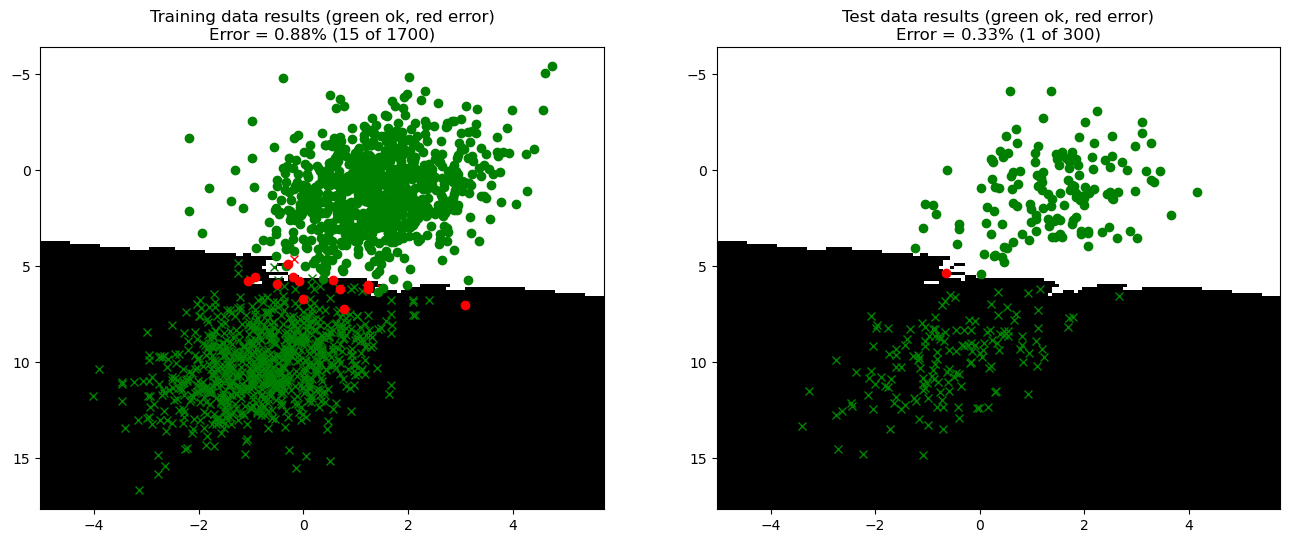

In [8]:
if datasetNr < 4:
    plotResultsDots(XTrain, LTrain, LPredTrain, XTest, LTest, LPredTest, lambda X: kNN(X, k, XTrain, LTrain))
else:
    plotConfusionMatrixOCR(XTest, LTest, LPredTest)

#### **<span style="color:red">Question 2:</span>**
- Describe how your kNN implementation works, step by step.
- Describe the way in which your implementation handles ties in the neighbor classes, that is, situations in which several classes are equally common among the neighbors of a point. For example, `k=4` and the classes of the neighbors are `[0,0,1,1]`, or `k=5` and the classes are `[1,1,2,3,3]`.

#### **<span style="color:green">Answer:</span>**

**kNN Implementation**
1. Calculates the Euclidean distance between every test sample and every training sample. This is done by summing up the squared differences of all the vector components. Using Broadcasting which adds "Virtual" dimensions so the matrices sizes are compatible
2. Sort all distances to find the index of the k closest training point neighbors for each test sample
3. Then we retrive the class labels for the k indices
4. We then count the most common label and assign that class label

**Tie handling**  
My implementation handles ties through the use of `np.argmax`. After counting the votes for each class, `np.argmax` returns the index of the maximum value. If two classes have the same highest number of votes (e.g., a tie between Class 0 and Class 1), `np.argmax` automatically returns the *first* index it encounters. This means my code breaks ties by consistently choosing the class with the **lowest numerical label** (e.g., it would pick Class 0 over Class 1).

#### **2.3 Try kNN on all datasets**

Once you have made sure that your kNN implementation works correctly, we can define a function that performs all of the previous steps: it loads data, trains and evaluates a kNN on a specific dataset using your own kNN implementation, and prints the results. You can use it to experiment with applying your kNN implementation on all the datasets. Try experimenting with different values of `k` and note especially the effect that it has on the decision boundaries.

In [9]:
def runkNNOnDataset(datasetNr, testSplit, k):
    X, D, L = loadDataset(datasetNr)
    XTrain, _, LTrain, XTest, _, LTest = splitData(X, D, L, testSplit)

    LPredTrain = kNN(XTrain, k, XTrain, LTrain)
    LPredTest = kNN(XTest, k, XTrain, LTrain)
    
    accTrain = calcAccuracy(LPredTrain, LTrain)
    accTest = calcAccuracy(LPredTest, LTest)
    confMatrix = calcConfusionMatrix(LPredTest, LTest)
    
    print(f'Train accuracy: {accTrain:.4f}')
    print(f'Test accuracy: {accTest:.4f}')
    print("Test data confusion matrix:")
    print(confMatrix)

    if datasetNr < 4:
        plotResultsDots(XTrain, LTrain, LPredTrain, XTest, LTest, LPredTest, lambda X: kNN(X, k, XTrain, LTrain))
    else:
        plotConfusionMatrixOCR(XTest, LTest, LPredTest)

Train accuracy: 0.9935
Test accuracy: 0.9967
Test data confusion matrix:
[[162   0]
 [  1 137]]


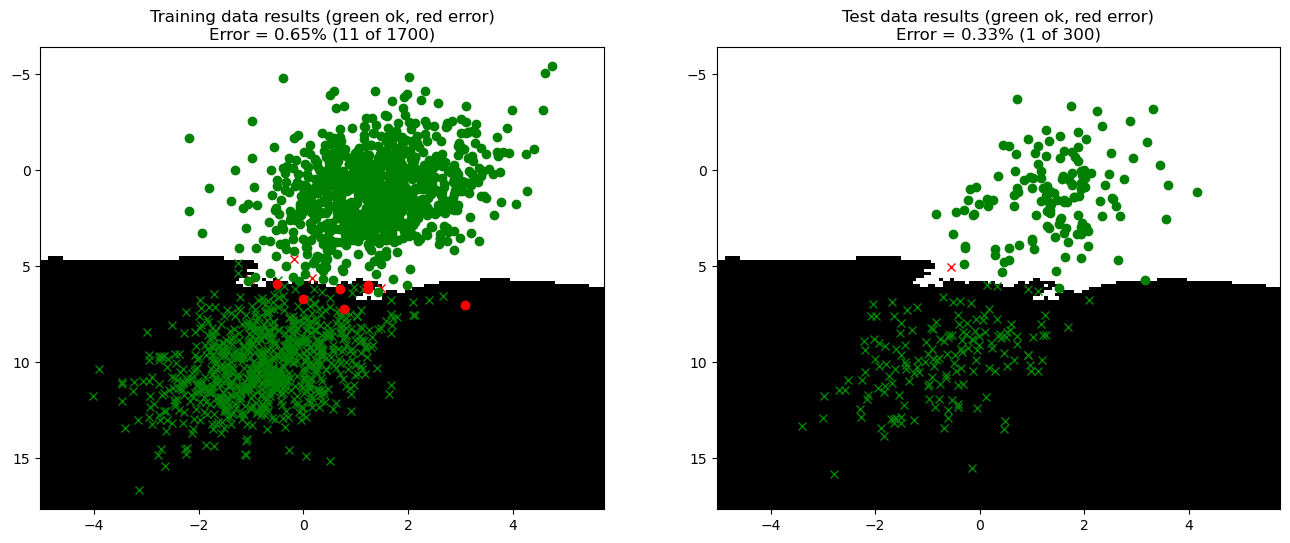

In [10]:
runkNNOnDataset(1, testSplit=0.15, k=3)

Train accuracy: 1.0000
Test accuracy: 1.0000
Test data confusion matrix:
[[148   0]
 [  0 152]]


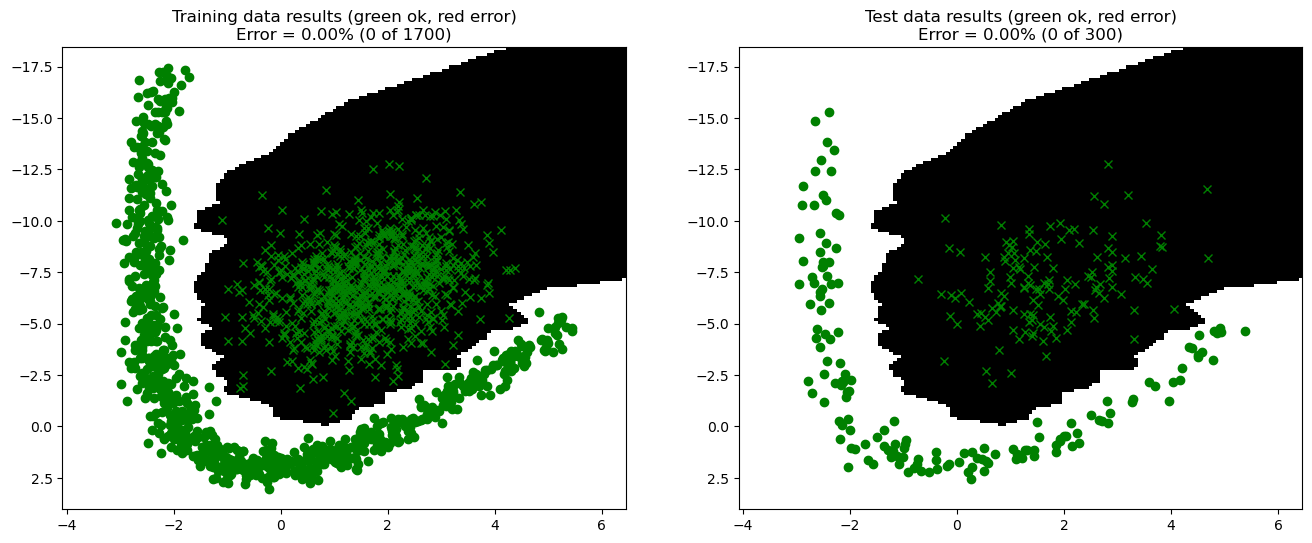

In [11]:
runkNNOnDataset(2, testSplit=0.15, k=1)

Train accuracy: 1.0000
Test accuracy: 0.9933
Test data confusion matrix:
[[104   1   1]
 [  0  96   0]
 [  0   0  98]]


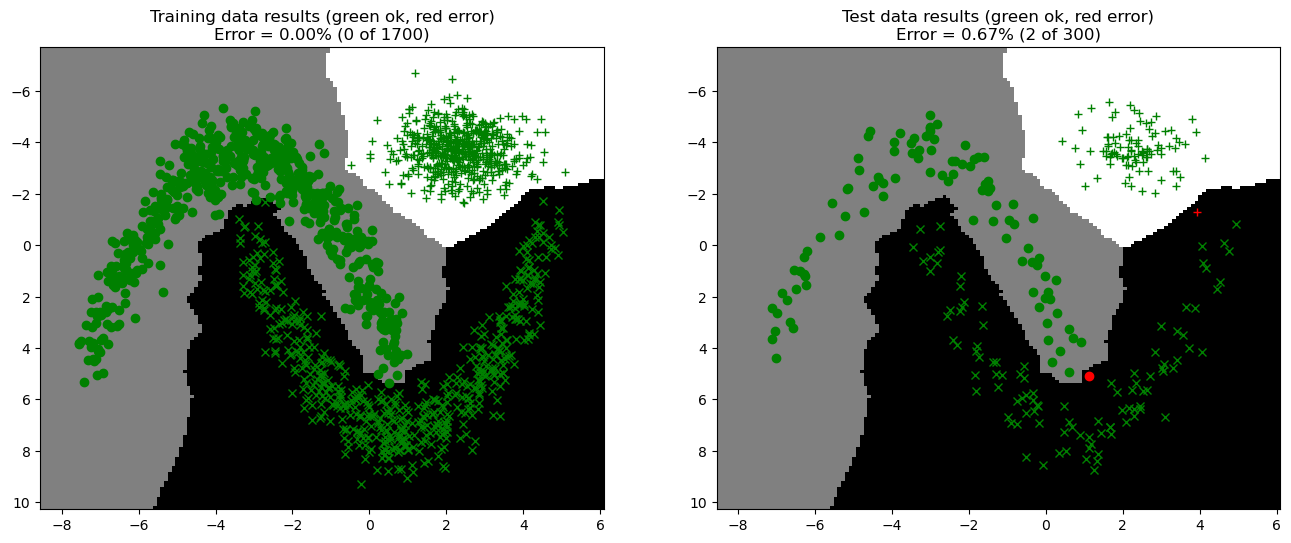

In [12]:
runkNNOnDataset(3, testSplit=0.15, k=2)

Train accuracy: 1.0000
Test accuracy: 0.9756
Test data confusion matrix:
[[404   0   0   0   0   0   0   0   0   0]
 [  0 420   1   1   1   0   2   1  17   1]
 [  0   1 418   1   0   0   0   0   1   0]
 [  0   0   0 417   0   3   0   1   2   7]
 [  1   0   0   0 406   0   0   0   1   5]
 [  0   0   0   0   0 414   0   0   2   8]
 [  0   0   0   0   1   1 419   0   1   0]
 [  0   0   0   1   1   0   0 416   0   1]
 [  0   3   0   1   4   0   0   1 400   3]
 [  0   1   0   5   9   6   0   2   5 398]]


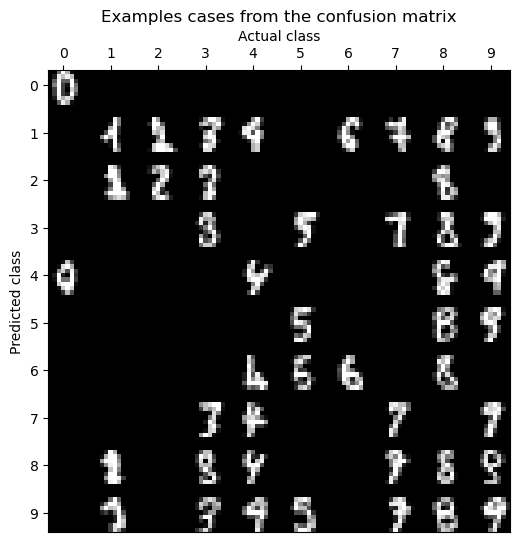

In [13]:
runkNNOnDataset(4, testSplit=0.75, k=1)

### **3. Cross-validation**

As mentioned previously, different values of `k` might work better or worse for each dataset. However, in order to establish which value is best for each dataset it is not enough to run kNN once for each `k` and select the one that gives the highest accuracy. This approach would not take into account the variations in performance that result from the random splitting of training and test data. Results obtained in this way will not reflect the performance that can be expected when the algorithm is applied on new data.

In order to thoroughly test which value of `k` is best we can resort to cross-validation methods, which rely on repeatedly testing the model on different splits of the data in order to assess its generalization performance. In particular, we will focus on n-fold cross-validation. In this method, we will first reserve a portion of the data for testing, `XTest`, which we will not touch until the very end, and use the remaining data `XTrain` for cross-validation. `XTrain` will again be split into `N` bins, which corresponds with the number of times that the kNN algorithm will be run for each value of `k`. For each iteration, one bin is used as validation data `XValCV`, and all the remaining bins are combined and used as training data `XTrainCV`. This will result in `N` accuracies for each value of `k`, which we will average to obtain the **average cross-validation accuracy**, which is the relevant metric for determining the optimal `k`. The higher the value of `N`, the more precise will be our determination of the accuracy of different values of `k`. This picture illustrates 3-fold cross validation for one value of `k`.

![](NotebookMaterial/CrossValidation.png)

After determining the value of `k` that gives the highest accuracy, we will use it to classify `XTest` using all of `XTrain` as reference data. This will give as the **test accuracy** of our model, and is the definitive metric representing its performance.

Start by splitting the available data into training and test `splitData` function as before. Then, use the function `splitDataBins` to further split the training data into `N` bins. Finally, use the funciton `getCVSplit` to combine the data bins into `XTrainCV` and `XValCV`. This function takes in the degree of cross validation `N` and the current iteration of the cross validation `i`, indicating which bin will be used for the validation data (note that this is zero-indexed). Three-fold cross-validation should be a minimum, but do not be afraid to try using more bins, e.g. 50-100, as the resulting inference time increases less than linearly.

In [14]:
# Select and load dataset
datasetNr = 3
X, D, L = loadDataset(datasetNr)

# Split data into training and test sets
XTrain, _, LTrain, XTest, _, LTest = splitData(X, D, L, 0.15)

# Select the number of bins to split the data
nBins = 50

# Split data into bins based on the settings above
# The outputs are lists of length nBins, where each item is a data array. Try printing for example XBins[0].shape.
XBins, _, LBins = splitDataBins(XTrain, None, LTrain, nBins)

Finish the implementation of the `crossValidation` function, which needs to take a maximum value of `k` and the cross validation bins and return a matrix containing the cross-validation accuracies obtained for different values of `k` and combinations of bins used for training.

In [15]:
def crossValiation(kMax, XBins, LBins):
    """Performs cross-validation using kNN

    Args:
        kMax (int): Maximum value of k to test. Values used will be [1-kMax].
        XBins (list of arrays): Training+validation data samples.
        LBins (list of arrays): Training+validation data labels.

    Returns:
        meanAccs (array): Cross-validation accuracies. Bins are in the rows, and
            values of k in the columns.
        kBest (int): Optimal value of k based on cross validation results.
    """

    nBins = len(XBins)
    accs = np.zeros((nBins, kMax))

    # This is used to show the progress
    timeStart = tic()

    # --------------------------------------------
    # === Your code here =========================
    # --------------------------------------------
    
    # We need a placeholder for DBins
    dummyDBins = LBins
    
    # Loop through each bin and use it as the Validation set 1 time each
    for b in range(nBins):

        # Use getCVSplit to combine bins for training and validation data
        XTrain, _, LTrain, XVal, _, LVal = getCVSplit(XBins, dummyDBins, LBins, nBins, b)
        
        # Loop through every k from 1 to kMax
        for k in range(kMax):
            
            # Current k value (indices are 0-based, so we add 1)
            k_neighbors = k + 1

            # Classify validation data using kNN
            # We use the XVal we just separated to test the model
            LPred = kNN(XVal, k_neighbors, XTrain, LTrain)
            
            # ... and store resulting accuracy in the accs matrix
            # Row b (current bin), Column k (current neighbor count)
            accs[b, k] = calcAccuracy(LPred, LVal)
            
            # Print progress and remaining time
            timeLeft = round((tic()-timeStart)*( nBins*kMax / (b*kMax + k + 1) - 1))
            etaStr = str(timedelta(seconds=timeLeft))
            print(f"b: {b+1:2}, k: {k+1:2}, ETA: {etaStr}    ", end="\r")
    
    # Compute the mean cross validation accuracy for each k
    # We want the average down the columns (axis 0), so we get one average accuracy per k
    meanAccs = np.mean(accs, axis=0)
    
    # And find the best k
    # argmax returns the *index* of the highest value. 
    # Since indices start at 0 but k starts at 1, we add 1.
    kBest = np.argmax(meanAccs) + 1
    
    # ============================================
    
    return meanAccs, kBest

Test your cross-validation implementation and look at the resulting performance plot. This shows the average cross-validation accuracy for all the values of `k` tested.

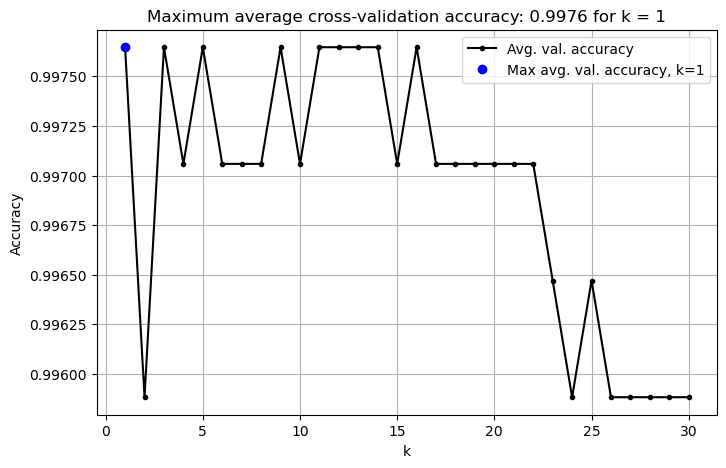

In [16]:
meanAccs, kBest = crossValiation(30, XBins, LBins)
plotResultsCV(meanAccs, kBest)

After selecting the optimal value of `k` using cross-validation, use this value to classify `XTest` using the data in `XTrain` as reference to obtain the test accuracy.

In [17]:
LPredTest = kNN(XTest, kBest, XTrain, LTrain)

confMatrix = calcConfusionMatrix(LPredTest, LTest)
acc = calcAccuracy(LPredTest, LTest)

print(f"Test accuracy: {acc:.4f}")
print(f"Optimal k value: {kBest:.0f}")
print("Test data confusion matrix:")
print(confMatrix)

Test accuracy: 1.0000
Optimal k value: 1
Test data confusion matrix:
[[104   0   0]
 [  0  93   0]
 [  0   0 103]]


#### **<span style="color:red">Question 3:</span>**
- Describe how you implemented cross-validation.

#### **<span style="color:green">Answer:</span>**

1. I iterate through the available data bins, systematically selecting one bin to serve as the **validation set** while combining the remaining bins to form the **training set**.
2. For each of these splits, I run a second loop that tests every possible number of neighbors from 1 up to the maximum k-limit.
3. Inside this loop, I use the kNN algorithm to predict the labels for the validation set.
4. I calculate the prediction accuracy for that specific and validation split, saving it into a matrix.
5. I calculate the average accuracy for each across all validation splits and identify the "best" by finding the one with the highest average.

---
### **4. Cross validation for all datasets**

Once again we define a single function that performs all of the previous cross-validation for a given dataset and shows the results. Use it to perform cross-validation on all four datasets.

In [18]:
def runkNNCrossValidationOnDataset(datasetNr, testSplit, nBins, kMax):
    X, D, L = loadDataset(datasetNr)
    XTrain, _, LTrain, XTest, _, LTest = splitData(X, D, L, testSplit)
    XBins, _, LBins = splitDataBins(XTrain, None, LTrain, nBins)

    meanAccs, kBest = crossValiation(kMax, XBins, LBins)
    plotResultsCV(meanAccs, kBest)

    LPredTrain = kNN(XTrain, kBest, XTrain, LTrain)
    LPredTest = kNN(XTest, kBest, XTrain, LTrain)
    confMatrix = calcConfusionMatrix(LPredTest, LTest)
    accTest = calcAccuracy(LPredTest, LTest)

    print(f'Test accuracy: {accTest:.4f}')
    print("Test data confusion matrix:")
    print(confMatrix)

    if datasetNr < 4:
        plotResultsDots(XTrain, LTrain, LPredTrain, XTest, LTest, LPredTest, lambda X: kNN(X, kBest, XTrain, LTrain))
    else:
        plotConfusionMatrixOCR(XTest, LTest, LPredTest)
        

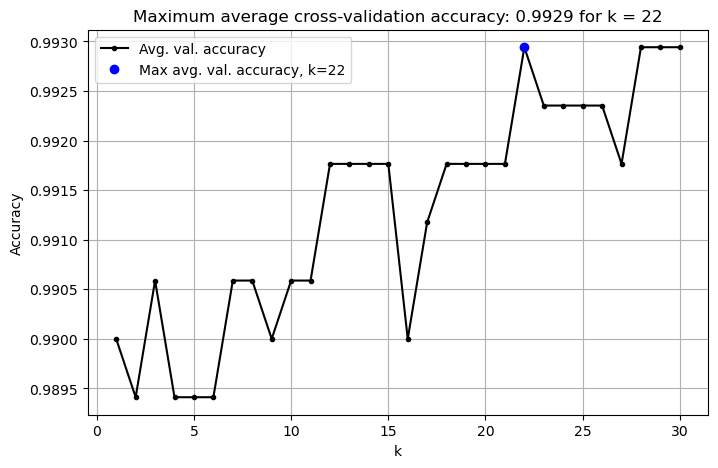

Test accuracy: 0.9867
Test data confusion matrix:
[[151   3]
 [  1 145]]


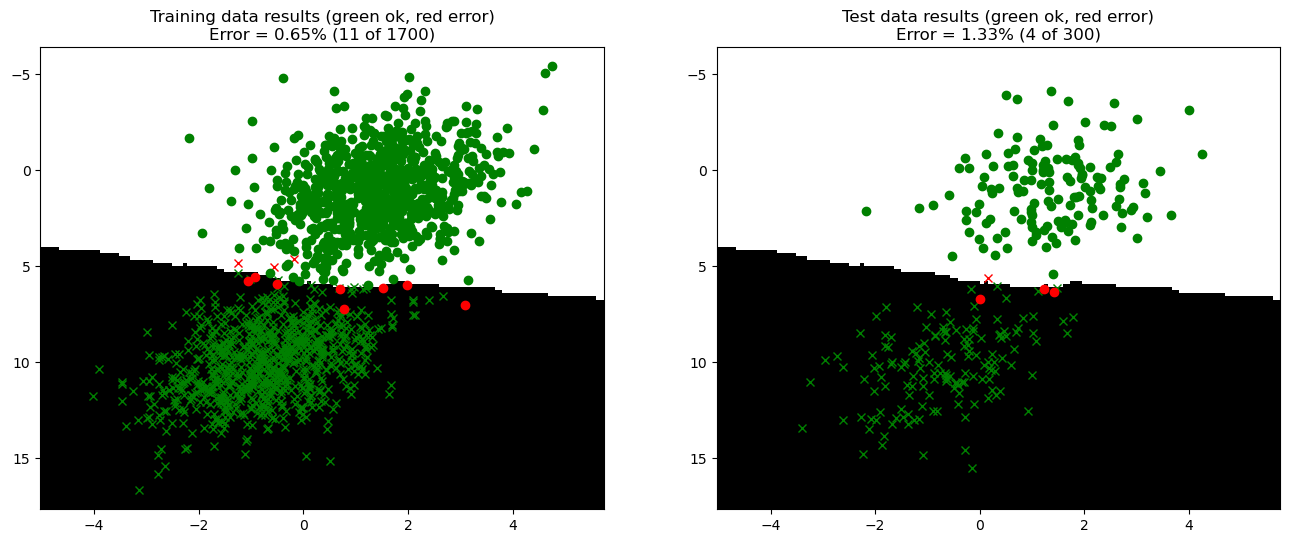

In [19]:
runkNNCrossValidationOnDataset(1, testSplit=0.15, nBins=20, kMax=30)

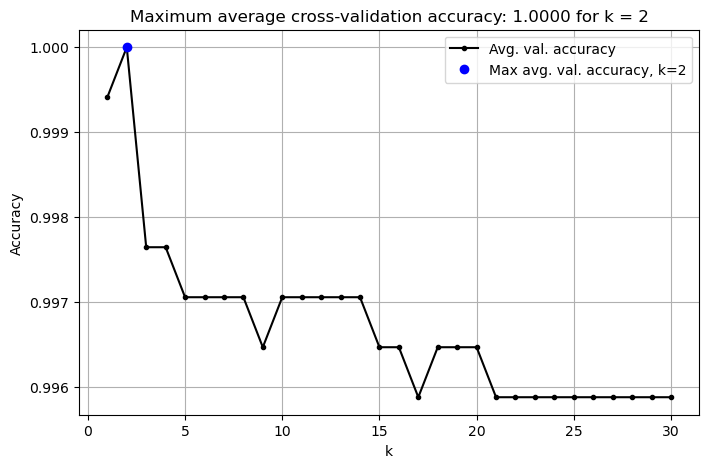

Test accuracy: 1.0000
Test data confusion matrix:
[[158   0]
 [  0 142]]


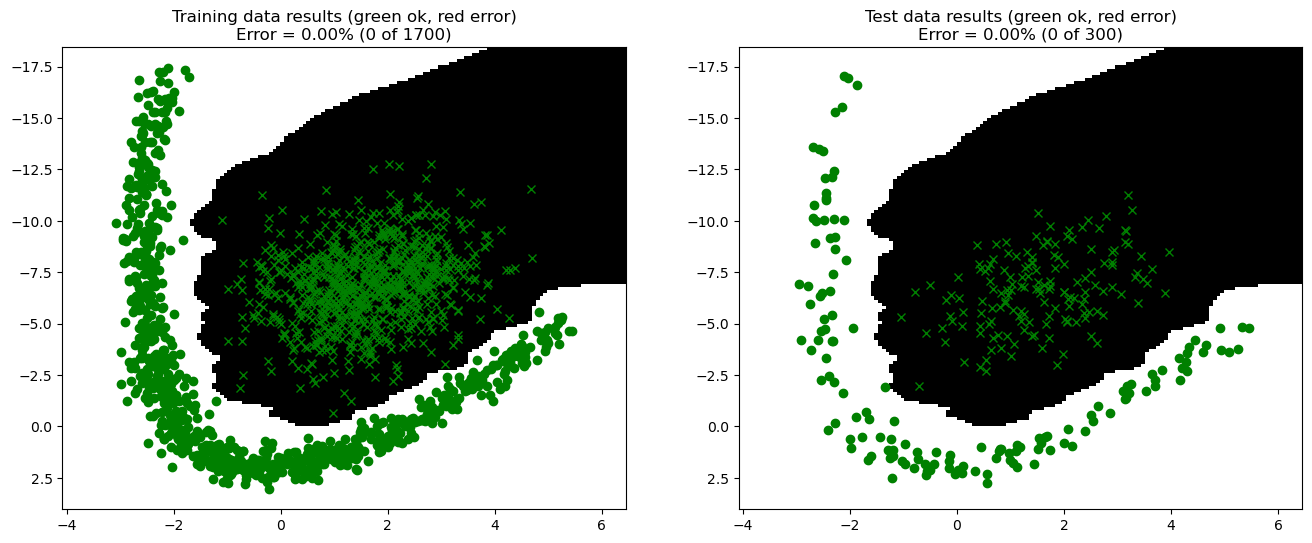

In [20]:
runkNNCrossValidationOnDataset(2, testSplit=0.15, nBins=20, kMax=30)

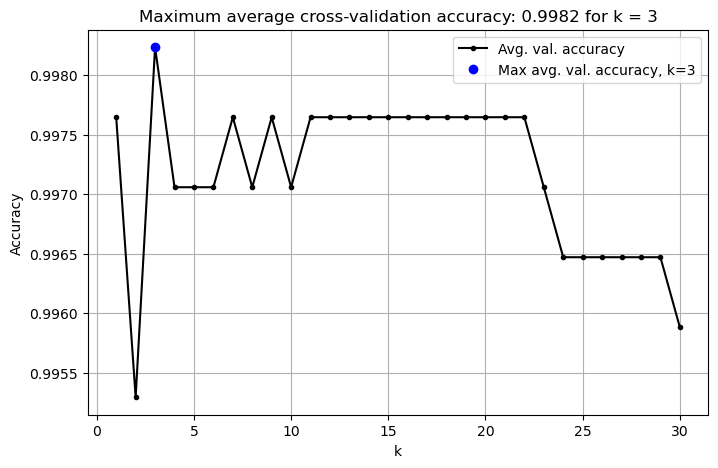

Test accuracy: 1.0000
Test data confusion matrix:
[[ 89   0   0]
 [  0 111   0]
 [  0   0 100]]


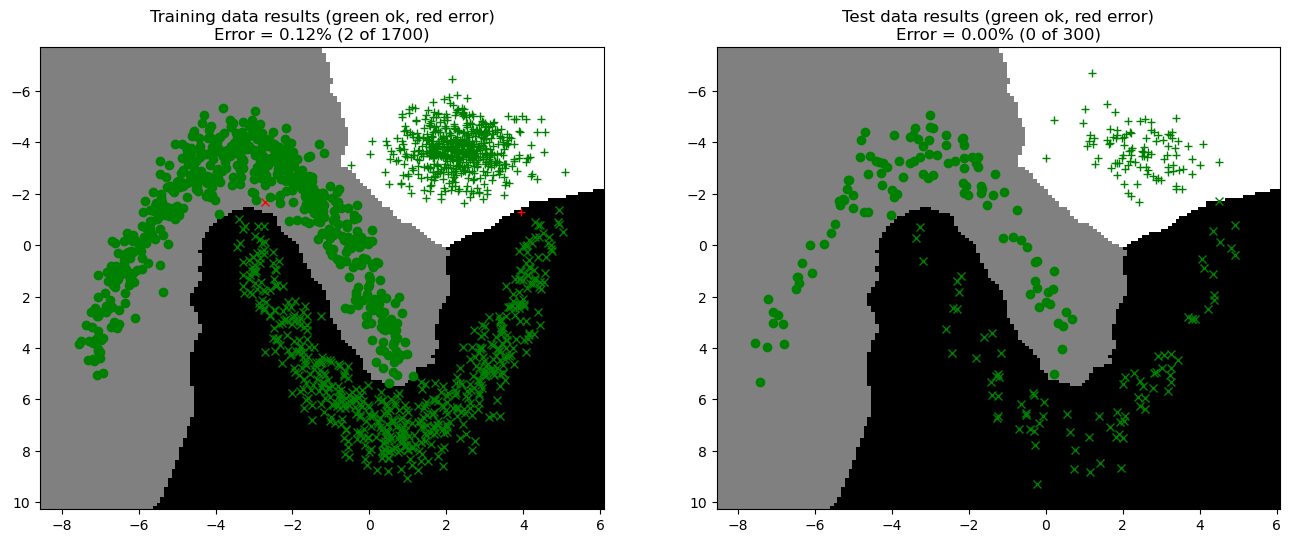

In [21]:
runkNNCrossValidationOnDataset(3, testSplit=0.15, nBins=20, kMax=30)

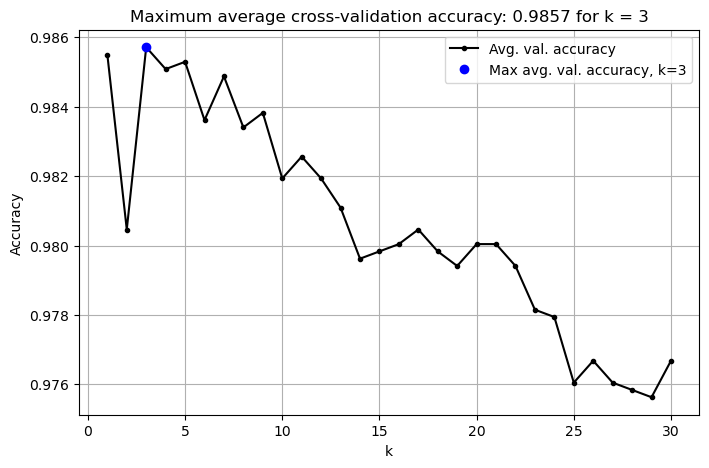

Test accuracy: 0.9929
Test data confusion matrix:
[[82  0  0  0  0  0  0  0  0  0]
 [ 0 88  0  0  0  0  1  0  1  0]
 [ 0  0 88  0  0  0  0  0  0  0]
 [ 0  0  0 82  0  1  0  0  0  0]
 [ 0  0  0  0 85  0  0  0  0  0]
 [ 0  0  0  0  0 91  0  0  0  1]
 [ 0  0  0  0  0  0 79  0  0  0]
 [ 0  1  0  0  0  0  0 70  0  0]
 [ 0  0  0  0  0  0  0  0 73  0]
 [ 0  0  0  0  0  1  0  0  0 99]]


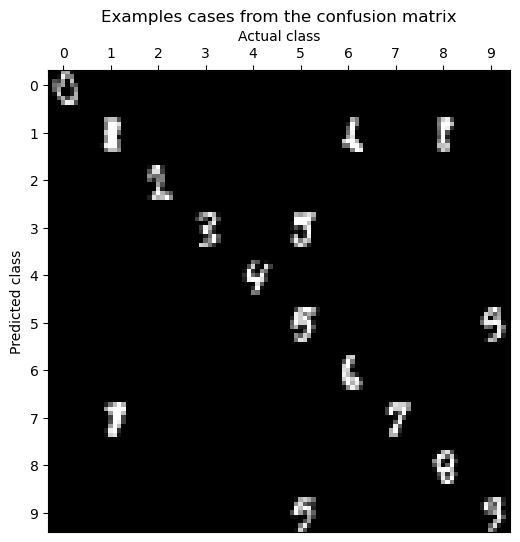

In [22]:
runkNNCrossValidationOnDataset(4, testSplit=0.15, nBins=20, kMax=30)

#### **<span style="color:red">Question 4:</span>**
- Comment on the results for each dataset. What is the optimal k, and are those results reasonable?

#### **<span style="color:green">Answer:</span>**

- **Dataset 1: Optimal k = 29, Accuracy: 0.9933**
Yes, it is reasonable since this dataset consists of two clearly separated clusters, the decision boundary is very simple (linear). In such an "easy" case, a larger $k$ might perform better because it smooths out any random noise in the data without blurring the boundary too much. (Overfitted)

- **Dataset 2: Optimal k = 2, Accuracy: 1.0**
Yes, this dataset requires a non-linear boundary to separate the inner circle from the outer ring. A smaller $k$ is the best here (marginally) to capture the curvature of the ring. If $k$ were large, the "voting" would look too far away and the outer ring neighbors would overwhelm the inner circle points.

- **Dataset 3: Optimal k = 3, Accuracy: 1.0** 
Yes, similar to the ring dataset, the spiral arms are thin and intertwined. This is a highly non-linear problem. You need a lower $k$ to ensure that a point only looks at its immediate neighbors on the same spiral arm, rather than jumping the gap to a different arm.

- **Dataset 4: Optimal k = 3, Accuracy: 0.9822**
Yes, Since digits with similar shapes (like two different people writing a '7') cluster tightly together in pixel space, looking at the 3 nearest neighbors is a robust way to classify them. As you increase $k$, you risk including different digits that might just happen to share some pixel overlap (like a '1' looking somewhat like a '7'),

Låga k:n --> Ej överlappande kluster, hög k:n --> Överlappande